In [1]:
from langfuse import get_client
from langfuse.langchain import CallbackHandler
# Initialize Langfuse client
langfuse = get_client()
# Initialize Langfuse CallbackHandler for Langchain (tracing)
langfuse_handler = CallbackHandler()

In [2]:
# Core LLM + tool + graph imports
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
# In-memory checkpoint store for multi-turn thread conversations
from langgraph.checkpoint.memory import MemorySaver


# Standard library typing/date utilities
from datetime import datetime
from typing import List, Optional, Annotated
from typing_extensions import TypedDict


In [3]:
# Initialize the base chat model and attach tracing callbacks
LLM = ChatNVIDIA(
    model="openai/gpt-oss-120b",
    # model="meta/llama-3.1-70b-instruct",
    temperature=0,
    callbacks=[langfuse_handler],
)

In [4]:
search_tool = GoogleSerperAPIWrapper()

@tool
def search(query: str) -> str:
    """Search the internet for information about a query and return the results.
    """
    return search_tool.run(query)

In [11]:
from pydantic import BaseModel


class AskUserInput(BaseModel):
    question: str

tools = [search, AskUserInput]

# bind the LLM to tools
llm_with_tools = LLM.bind_tools(tools)

# Define the state graph for the agent
class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

# defining the nodes

def agent_node(state: State) -> str:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}



graph_builder.add_node( "agent", agent_node)

tool_node = ToolNode(tools=[search])
graph_builder.add_node("tool_node", tool_node)

def ask_user_node(state: State) -> str:
    
    return {"messages":[]}

graph_builder.add_node("ask_user", ask_user_node)

In [12]:
def routing_condition(state: State) -> str:
    last_message = state["messages"][-1]
    if not last_message.tool_calls:
        return END
    elif last_message.tool_calls[0]["name"] == "AskUserInput":
        return "ask_user"
    else:        
        return "tool_node"

In [13]:
# Addingconditional edges
graph_builder.add_conditional_edges("agent", routing_condition,
                       {
                           END:END,
                            "ask_user":"ask_user",
                            "tool_node":"tool_node"})

In [14]:
memory = MemorySaver()
graph_builder.add_edge("tool_node", "agent")

graph_builder.add_edge("ask_user", "agent")
# Initialize the graph with the initial state and checkpoint saver
graph_builder.set_entry_point("agent")
graph = graph_builder.compile(
    checkpointer=memory
    ,interrupt_before=["ask_user"]
)

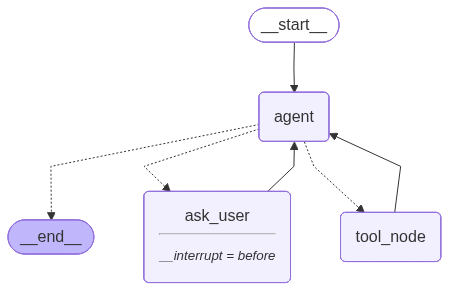

In [15]:
graph

In [41]:
user_input = "What is the weather"

config_1 = {
    "configurable": {"thread_id": "8"}
}

# invoke the graph with the user input and config
events = graph.stream(
    {"messages": [("user", user_input)]}, 
    config=config_1,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()





================================ Human Message =================================

What is the weather
================================== Ai Message ==================================
Tool Calls:
  AskUserInput (chatcmpl-tool-a0f542298a0311b7)
 Call ID: chatcmpl-tool-a0f542298a0311b7
  Args:
    question: Sure, could you tell me which location you would like the weather for?


In [42]:
snapshot = graph.get_state(config_1)
print("next Nodes to execute: ", snapshot.next)

next Nodes to execute:  ('ask_user',)


In [43]:
from langchain_core.messages import ToolMessage

tool_call_id = snapshot.values["messages"][-1].tool_calls[0]["id"]
user_response = ToolMessage(
    tool_call_id=tool_call_id,
    content="The weather in New Delhi, India: South Delhi, Chhatarpur.",
)

# Update the state with the user response and continue execution
graph.update_state(config_1, {"messages": [user_response]}, as_node="ask_user")

{'configurable': {'thread_id': '8',
  'checkpoint_ns': '',
  'checkpoint_id': '1f13b02f-19f2-6c7f-8002-ef9dfb0f8809'}}

In [44]:
events = graph.stream(None, 
    config=config_1,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()


================================= Tool Message =================================

The weather in New Delhi, India: South Delhi, Chhatarpur.
================================== Ai Message ==================================
Tool Calls:
  search (chatcmpl-tool-81d4b99dbdb49737)
 Call ID: chatcmpl-tool-81d4b99dbdb49737
  Args:
    query: current weather New Delhi South Delhi Chhatarpur
================================= Tool Message =================================
Name: search

103°F
================================== Ai Message ==================================
Tool Calls:
  search (chatcmpl-tool-bf05be0cc45d41c0)
 Call ID: chatcmpl-tool-bf05be0cc45d41c0
  Args:
    query: New Delhi weather temperature now
================================= Tool Message =================================
Name: search

103°F
================================== Ai Message ==================================
Tool Calls:
  search (chatcmpl-tool-bdbc495f933aea4d)
 Call ID: chatcmpl-tool-bdbc495f933aea4d
  Args:
 